# Minimum Detectable Effect (MDE)

## Overview

The MDE is the smallest effect size that the study is powered to detect. It should be defined before the study as the smallest effect that would be **scientifically or practically meaningful** — not the smallest effect that happens to be detectable given a convenient sample size.

**MDE vs. expected effect:**
- **Expected effect:** what you believe the true effect is
- **MDE:** the smallest effect worth acting on
- If MDE > expected effect: the study will likely be underpowered
- If MDE << expected effect: the study is overpowered; n could be reduced

**Sources for MDE specification:**

| Source | Reliability | Notes |
|---|---|---|
| Pilot data | High | Best estimate of σ; effect size still uncertain |
| Published literature | Medium | Effect may not transfer to your population |
| Clinical / regulatory threshold | High | Pre-specified meaningful threshold |
| Cohen's conventions | Low | Last resort; domain-agnostic |
| Smallest effect of economic value | High | Used in industry A/B testing |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(pwr)
library(patchwork)

# ── Context: restoration monitoring programme ─────────────────────────────────
# Question: what is the smallest richness increase we care about detecting?
# Pilot data: σ ≈ 5 species, baseline mean ≈ 18 species

sigma    <- 5
baseline <- 18

# ── Define MDE from different perspectives ────────────────────────────────────
cat("MDE specification approaches:\n")
cat(sprintf("  Ecological threshold: 2 species (%.1f%% change) → d=%.2f\n",
            2/baseline*100, 2/sigma))
cat(sprintf("  Regulatory criterion: 20%% increase = 3.6 species → d=%.2f\n",
            baseline*0.2/sigma))
cat(sprintf("  Cohen medium:         d=0.50 = %.1f species\n",
            0.5*sigma))
cat(sprintf("  Economic breakeven:   1 species (smallest justifiable cost) → d=%.2f\n",
            1/sigma))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'pwr' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version 4.4.

MDE specification approaches:
  Ecological threshold: 2 species (11.1% change) → d=0.40
  Regulatory criterion: 20% increase = 3.6 species → d=0.72
  Cohen medium:         d=0.50 = 2.5 species
  Economic breakeven:   1 species (smallest justifiable cost) → d=0.20


---

## MDE as a Function of Sample Size

# A tibble: 3 × 5
  threshold  mde_species     d n_per_group n_total
  <chr>            <dbl> <dbl>       <dbl>   <dbl>
1 economic           1    0.2          394     788
2 ecological         2    0.4          100     200
3 regulatory         3.6  0.72          32      64


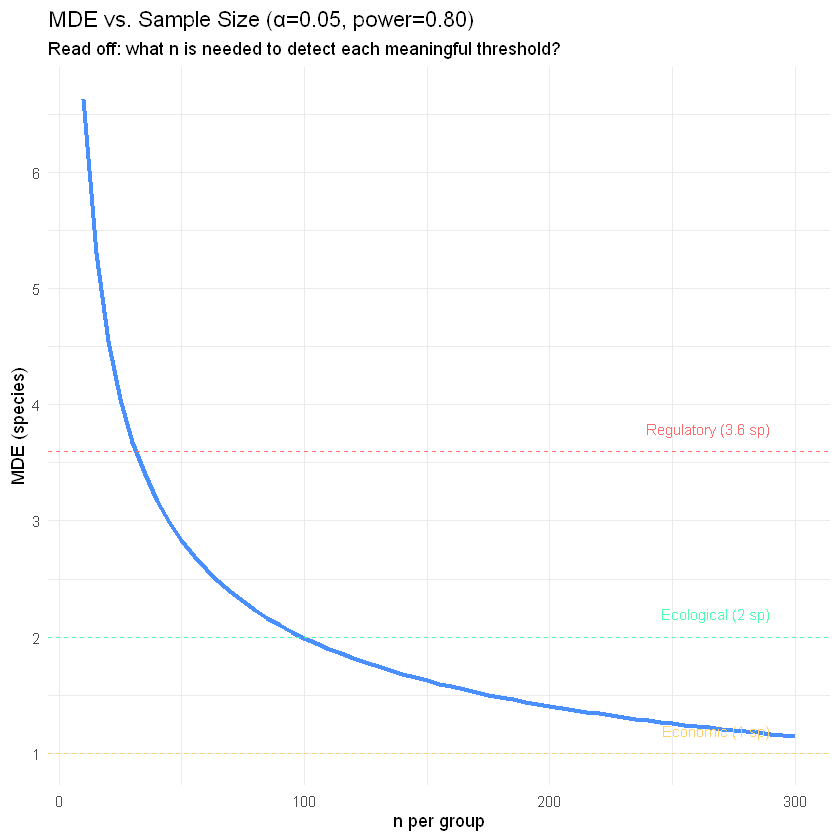

In [2]:
# For a given n, what is the minimum effect we can detect at 80% power?
mde_curve <- tibble(
  n = seq(10, 300, by=5)
) %>%
  mutate(
    d_mde = map_dbl(n, ~pwr::pwr.t.test(
      n=.x, sig.level=0.05, power=0.80,
      type="two.sample", alternative="two.sided"
    )$d),
    effect_species = d_mde * sigma
  )

p_mde <- ggplot(mde_curve, aes(x=n, y=effect_species)) +
  geom_line(color="#4a8fff", linewidth=1.2) +
  geom_hline(yintercept=c(1, 2, 3.6), linetype="dashed",
             color=c("#ffd166","#4fffb0","#ff6b6b")) +
  annotate("text", x=290, y=1.2, label="Economic (1 sp)",
           color="#ffd166", hjust=1, size=3.2) +
  annotate("text", x=290, y=2.2, label="Ecological (2 sp)",
           color="#4fffb0", hjust=1, size=3.2) +
  annotate("text", x=290, y=3.8, label="Regulatory (3.6 sp)",
           color="#ff6b6b", hjust=1, size=3.2) +
  labs(title="MDE vs. Sample Size (α=0.05, power=0.80)",
       subtitle="Read off: what n is needed to detect each meaningful threshold?",
       x="n per group", y="MDE (species)") +
  theme_minimal()

# Required n to detect each threshold
thresholds <- c(economic=1, ecological=2, regulatory=3.6)
map_dfr(names(thresholds), function(nm) {
  d   <- thresholds[nm] / sigma
  req <- pwr::pwr.t.test(d=d, sig.level=0.05, power=0.80,
                          type="two.sample", alternative="two.sided")
  tibble(threshold=nm, mde_species=thresholds[nm], d=round(d,3),
         n_per_group=ceiling(req$n), n_total=ceiling(req$n)*2)
}) %>% print()

p_mde

---

## Uncertainty in the MDE: Sensitivity to σ

# A tibble: 11 × 4
   sigma     d n_per_group n_total
   <dbl> <dbl>       <dbl>   <dbl>
 1   3    0.67          37      74
 2   3.5  0.57          50     100
 3   4    0.5           64     128
 4   4.5  0.44          81     162
 5   5    0.4          100     200
 6   5.5  0.36         120     240
 7   6    0.33         143     286
 8   6.5  0.31         167     334
 9   7    0.29         194     388
10   7.5  0.27         222     444
11   8    0.25         253     506

Recommended n with 25% buffer: 250 total (125 per group)


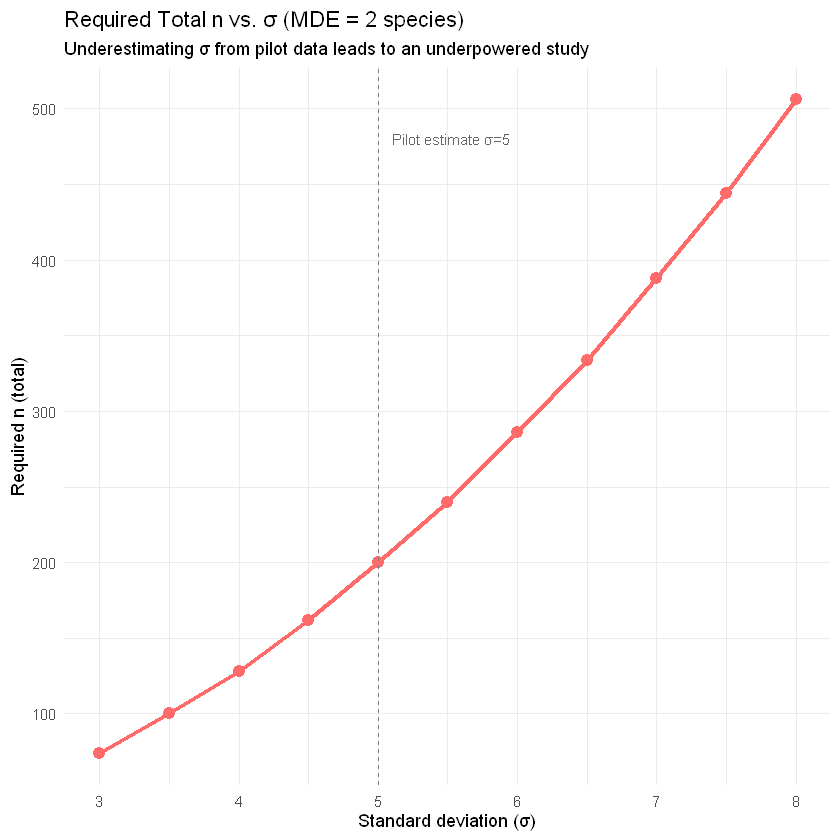

In [3]:
# σ is estimated from pilot data and has its own uncertainty
# Sensitivity analysis: how much does required n change if σ is misspecified?

mde_species <- 2   # fixed ecological threshold
sigma_range <- seq(3, 8, by=0.5)  # plausible range of σ

sigma_sens <- tibble(sigma=sigma_range) %>%
  mutate(
    d          = mde_species / sigma,
    n_per_group= map_dbl(d, ~ceiling(pwr::pwr.t.test(
      d=.x, sig.level=0.05, power=0.80,
      type="two.sample", alternative="two.sided")$n)),
    n_total    = n_per_group * 2
  )

p_sigma <- ggplot(sigma_sens, aes(x=sigma, y=n_total)) +
  geom_line(color="#ff6b6b", linewidth=1.2) +
  geom_point(size=3, color="#ff6b6b") +
  geom_vline(xintercept=5, linetype="dashed", color="gray50") +
  annotate("text", x=5.1, y=max(sigma_sens$n_total)*0.95,
           label="Pilot estimate σ=5", hjust=0, color="gray40", size=3.2) +
  labs(title="Required Total n vs. σ (MDE = 2 species)",
       subtitle="Underestimating σ from pilot data leads to an underpowered study",
       x="Standard deviation (σ)", y="Required n (total)") +
  theme_minimal()

print(sigma_sens %>% mutate(across(where(is.numeric), ~round(.x, 2))))
p_sigma

# Recommendation: add 20-30% buffer to n to account for σ uncertainty
buffer_n <- ceiling(sigma_sens$n_total[sigma_sens$sigma==5] * 1.25)
cat(sprintf("\nRecommended n with 25%% buffer: %d total (%d per group)\n",
            buffer_n, ceiling(buffer_n/2)))

---

## Common Pitfalls

**1. Choosing the MDE to match available sample size rather than meaningful effect**  
"We have 30 sites, so we can detect d=0.75 — is that meaningful?" inverts the logic. The MDE must be chosen on scientific grounds first, then n calculated to detect it. If the required n is infeasible, the study should be redesigned or the research question revised — not the MDE adjusted downward to match convenience.

**2. Using the effect size from the literature as the MDE**  
Published effects are biased upward due to publication bias — journals preferentially publish large, significant effects. Using a published effect as the expected MDE typically produces a study that is too small. Use the lower bound of the CI from published effects, or a conservative estimate from a well-powered study, as the basis for the MDE.

**3. Not propagating uncertainty in σ to the sample size calculation**  
The standard deviation estimated from a pilot study of n=20 is itself uncertain (±30–50%). A larger true σ than estimated means the actual power is below the nominal level. Always conduct a sensitivity analysis across a plausible range of σ and add a buffer (typically 15–25%) to the calculated n.

**4. Reporting the MDE as if it were the expected effect**  
"The study was powered to detect a 2-species increase" does not mean a 2-species increase is expected or was observed. The MDE is the sensitivity floor of the study — the smallest signal it can reliably find. Conflating it with the expected or observed effect misrepresents what the power analysis established.

**5. Calculating MDE for the primary outcome only**  
Studies with multiple outcomes have different MDEs for each. A study powered for the primary outcome may be grossly underpowered for secondary outcomes with higher variability or smaller expected effects. Document the MDE and power for each outcome separately, and treat underpowered secondary outcomes as exploratory.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*